In [1]:
import pandas as pd
import seaborn as sns
import pingouin as pg
import numpy as np
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr
from sklearn.cross_decomposition import CCA
from numpy.linalg import svd
from statsmodels.multivariate.cancorr import CanCorr
from sparsecca import pmd
from sklearn.model_selection import KFold
import itertools
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
import miceforest as mf
from fancyimpute import SoftImpute
from sklearn.impute import SimpleImputer

### 1. Canonical corrleation analysis - 정준상관분석

두 변수 사이의 공통으로 작동하는 축을 찾아 두 집합의 연관 구조를 알고싶을 때 사용하는 분석 기법

In [3]:
# 데이터셋 불러오기 - taxi 데이터셋
df = sns.load_dataset('taxis')

In [28]:
X = df[['distance','tolls']]
Z = df[['fare', 'tip' ]]

scaler_X = StandardScaler()
scaler_Z = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
Z_scaled = scaler_Z.fit_transform(Z)

In [29]:
# 최대 가능한 컴포넌트 수
max_k = min(X.shape[1], Z.shape[1], X.shape[0]-1)

# 모든 컴포넌트에 대해 CCA 실행
cca = CCA(n_components=max_k)
U, V = cca.fit_transform(X, Z)

# 각 컴포넌트의 canonical correlation 계산
cors = []
for i in range(max_k):
    r = np.corrcoef(U[:, i], V[:, i])[0, 1]
    cors.append(r)
# 급격히 떨어지는 지점 찾기 
best_n = 1
for i in range(len(cors)-1):
    if cors[i] - cors[i+1] > 0.1:
        best_n = i + 1
        break
else:
    best_n = len([c for c in cors if c > 0.1])  # 0.1 이상인 컴포넌트 수

print(f"Recommended n_components: {best_n}")

Recommended n_components: 1


In [31]:
# Permutation Test - 결과가 우연하게 나오는지 확인하는 검증
# p-value가 0.05보다 작으면 유의미하다고 판단

def cca_statistic(X_scaled, Z_scaled):
    cca = CCA(n_components=1)
    U, V = cca.fit_transform(X_scaled, Z_scaled)
    return pearsonr(U[:, 0], V[:, 0])[0]  # correlation만 반환

# Observed correlation
r_obs = cca_statistic(X_scaled, Z_scaled)
print(f"\n=== Permutation Test ===")
print(f"Observed correlation: {r_obs:.6f}")

# Permutation test
B = 1000  # permutation 횟수
rng = np.random.default_rng(0)
r_perm = []

for i in range(B):
    # X의 행을 무작위로 섞음
    idx = rng.permutation(X_scaled.shape[0])
    X_perm = X_scaled[idx, :]
    r_perm.append(cca_statistic(X_perm, Z_scaled))
r_perm = np.array(r_perm)

# p-value 계산
p_perm = np.mean(np.abs(r_perm) >= np.abs(r_obs))

print(f"Permutation p-value: {p_perm:.4f}")

# 변수 중요도
X_cols = ['distance','tolls']
wX = pd.Series(cca.x_weights_[:, 0], index=X_cols).sort_values(key=np.abs, ascending=False)
print("\nX 변수 중요도")
print(wX)

Z_cols = ['fare', 'tip', ]
wZ = pd.Series(cca.y_weights_[:, 0], index=Z_cols).sort_values(key=np.abs, ascending=False)
print("\nZ 변수 중요도")
print(wZ)


=== Permutation Test ===
Observed correlation: 0.920717
Permutation p-value: 0.0000

X 변수 중요도
distance    0.998794
tolls       0.049104
dtype: float64

Z 변수 중요도
fare    0.999927
tip     0.012115
dtype: float64


### 2. Sparse CCA - 희소 정준상관분석

두 변수 집합의 공통 패턴을 찾되, 변수 수가 많을 때 핵심 변수만 선택해 해석함

주로 변수가 많은 경우에 사용

In [15]:
from sklearn.datasets import load_diabetes
X_all, y = load_diabetes(return_X_y=True, as_frame=True)

X = X_all[['bp','s1','s2','s3', 's4']]
Z = X_all[['s5','s6','age','sex', 'bmi']]

# z-score 표준화 
X = ((X - X.mean(axis=0)) / (X.std(axis=0) + 1e-12)).to_numpy()
Z = ((Z - Z.mean(axis=0)) / (Z.std(axis=0) + 1e-12)).to_numpy()

# X 변수 이름
X_cols =['bp','s1','s2','s3', 's4']
# Z 변수 이름
Z_cols = ['s5','s6','age','sex', 'bmi']

##### sparse cca 함수

In [34]:
def apply_sparse_cca(X, Z, X_cols=None, Z_cols=None, 
                     standardize=True, 
                     find_best_n=True,
                     find_best_penalty=True,
                     penalty_range=None,
                     n_components=None,
                     penaltyu=None,
                     penaltyv=None,
                     n_splits=5,
                     random_state=42,
                     do_permutation_test=True,
                     n_permutations=1000,
                     visualize=True,
                     verbose=True):
    
    # 데이터 준비
    if isinstance(X, pd.DataFrame):
        X = X.values
    if isinstance(Z, pd.DataFrame):
        Z = Z.values
    
    # 표준화
    if standardize:
        X = ((X - X.mean(axis=0)) / (X.std(axis=0) + 1e-12))
        Z = ((Z - Z.mean(axis=0)) / (Z.std(axis=0) + 1e-12))
    
    # 1. 컴포넌트 수 설정 (항상 1로 고정)
    if find_best_n:
        best_n = 1
        if verbose:
            print("=" * 50)
            print("Using n_components = 1")

    else:
        if n_components is None:
            raise ValueError("n_components must be specified when find_best_n=False")
        best_n = n_components
    
    # 2. 최적 penalty 파라미터 찾기
    if find_best_penalty:
        if verbose:
            print("=" * 50)
            print("Grid search for best penalty parameters...")

        
        if penalty_range is None:
            penalty_range = np.arange(0.1, 1.0, 0.1)
        
        kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
        best_score = -np.inf
        best_penaltyu = None
        best_penaltyv = None
        results_grid = []
        
        for penaltyu, penaltyv in itertools.product(penalty_range, penalty_range):
            cv_scores = []
            
            for train_idx, val_idx in kf.split(X):
                X_train, X_val = X[train_idx], X[val_idx]
                Z_train, Z_val = Z[train_idx], Z[val_idx]
                
                try:
                    U, V, D = pmd(X_train.T @ Z_train, K=best_n,
                                 penaltyu=penaltyu, penaltyv=penaltyv,
                                 standardize=False)
                    
                    X_scores = X_val @ U[:, :best_n]
                    Z_scores = Z_val @ V[:, :best_n]
                    
                    corrs = []
                    for k in range(best_n):
                        rk = np.corrcoef(X_scores[:, k], Z_scores[:, k])[0, 1]
                        if not np.isnan(rk):
                            corrs.append(rk)
                    
                    if len(corrs) > 0:
                        cv_scores.append(np.mean(corrs))
                except:
                    continue
            
            if len(cv_scores) > 0:
                mean_score = np.mean(cv_scores)
                results_grid.append((penaltyu, penaltyv, mean_score))
                
                if mean_score > best_score:
                    best_score = mean_score
                    best_penaltyu = penaltyu
                    best_penaltyv = penaltyv
        
        if verbose:
            print(f"Best penaltyu: {best_penaltyu:.3f}")
            print(f"Best penaltyv: {best_penaltyv:.3f}")
            print(f"Best CV score: {best_score:.4f}\n")
    else:
        if penaltyu is None or penaltyv is None:
            raise ValueError("penaltyu and penaltyv must be specified when find_best_penalty=False")
        best_penaltyu = penaltyu
        best_penaltyv = penaltyv
    
    # 3. 전체 데이터에 Sparse CCA 적용
    if verbose:
        print("=" * 50)
        print("Applying Sparse CCA with best parameters...")
        print(f"penaltyu = {best_penaltyu:.3f}, penaltyv = {best_penaltyv:.3f}, n_components = {best_n}")
        print("=" * 50)
    
    U, V, D = pmd(X.T @ Z, K=best_n,
                 penaltyu=best_penaltyu,
                 penaltyv=best_penaltyv,
                 standardize=False)
    
    X_scores = X @ U[:, :best_n]
    Z_scores = Z @ V[:, :best_n]
    
    # 각 컴포넌트의 canonical correlation 계산
    sparse_cors = []
    for k in range(best_n):
        rk = np.corrcoef(X_scores[:, k], Z_scores[:, k])[0, 1]
        sparse_cors.append(rk)
        if verbose:
            print(f"Sparse CCA Component {k+1}: correlation = {rk:.4f}")
    
    if verbose:
        print(f"\nAverage correlation: {np.mean(sparse_cors):.4f}\n")
    
    # 4. Weights 확인
    if X_cols is None:
        X_cols = [f'X_{i}' for i in range(X.shape[1])]
    if Z_cols is None:
        Z_cols = [f'Z_{i}' for i in range(Z.shape[1])]
    
    X_weights_dict = {}
    Z_weights_dict = {}
    
    for k in range(best_n):
        x_weights = pd.Series(U[:, k], index=X_cols)
        z_weights = pd.Series(V[:, k], index=Z_cols)
        
        if verbose:
            print(f"=== Component {k+1} ===")
            print("\nX Weights:")
            print(x_weights.sort_values(key=abs, ascending=False))
            print(f"Non-zero weights: {(x_weights != 0).sum()} / {len(x_weights)}")
            print("\nZ Weights:")
            print(z_weights.sort_values(key=abs, ascending=False))
            print(f"Non-zero weights: {(z_weights != 0).sum()} / {len(z_weights)}\n")
        
        X_weights_dict[f'Component_{k+1}'] = x_weights
        Z_weights_dict[f'Component_{k+1}'] = z_weights
    
    # 5. 시각화
    if visualize:
        fig, axes = plt.subplots(1, best_n, figsize=(6*best_n, 5))
        if best_n == 1:
            axes = [axes]
        
        for k in range(best_n):
            axes[k].scatter(X_scores[:, k], Z_scores[:, k], alpha=0.6)
            axes[k].set_xlabel(f'X Canonical Score (Component {k+1})')
            axes[k].set_ylabel(f'Z Canonical Score (Component {k+1})')
            axes[k].set_title(f'Component {k+1}: r = {sparse_cors[k]:.4f}')
            axes[k].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    # 6. Permutation Test
    permutation_pvalue = None
    if do_permutation_test:
        if verbose:
            print("Permutation Test for Statistical Significance")
            print("=" * 50)
        
        def sparse_cca_statistic(X, Z, penaltyu, penaltyv, n_components):
            """Sparse CCA를 수행하고 canonical correlation의 합을 반환"""
            try:
                U, V, D = pmd(X.T @ Z, K=n_components,
                             penaltyu=penaltyu, penaltyv=penaltyv, standardize=False)
                
                X_scores = X @ U[:, :n_components]
                Z_scores = Z @ V[:, :n_components]
                
                corrs = []
                for k in range(n_components):
                    rk = np.corrcoef(X_scores[:, k], Z_scores[:, k])[0, 1]
                    if not np.isnan(rk):
                        corrs.append(rk)
                
                stat = np.sum(np.array(corrs)**2) if len(corrs) > 0 else 0.0
                return stat
            except:
                return 0.0
        
        r_obs = sparse_cca_statistic(X, Z, best_penaltyu, best_penaltyv, best_n)
        if verbose:
            print(f"Observed statistic (sum of squared correlations): {r_obs:.6f}")
            print(f"Running {n_permutations} permutations...")
        
        rng = np.random.default_rng(random_state)
        r_perm = []
        
        for i in range(n_permutations):
            idx = rng.permutation(X.shape[0])
            X_perm = X[idx, :]
            r_perm.append(sparse_cca_statistic(X_perm, Z, best_penaltyu, best_penaltyv, best_n))

        
        r_perm = np.array(r_perm)
        permutation_pvalue = np.mean(r_perm >= r_obs)
        
        if verbose:
            print(f"\nPermutation p-value: {permutation_pvalue:.4f}")
            print(f"95% percentile of permuted statistics: {np.percentile(r_perm, 95):.6f}")
            print(f"99% percentile of permuted statistics: {np.percentile(r_perm, 99):.6f}")
        
        if visualize:
            plt.figure(figsize=(10, 6))
            plt.hist(r_perm, bins=50, alpha=0.7, edgecolor='black', label='Permuted statistics')
            plt.axvline(r_obs, color='red', linestyle='--', linewidth=2, label=f'Observed ({r_obs:.4f})')
            plt.axvline(np.percentile(r_perm, 95), color='orange', linestyle=':', linewidth=2, label='95th percentile')
            plt.xlabel('Test Statistic (Sum of Squared Correlations)')
            plt.ylabel('Frequency')
            plt.title(f'Permutation Test Distribution\np-value = {permutation_pvalue:.4f}')
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.show()
    
    # 결과 반환
    results = {
        'best_n': best_n,
        'best_penaltyu': best_penaltyu,
        'best_penaltyv': best_penaltyv,
        'correlations': sparse_cors,
        'X_weights': X_weights_dict,
        'Z_weights': Z_weights_dict,
        'X_scores': X_scores,
        'Z_scores': Z_scores,
        'permutation_pvalue': permutation_pvalue
    }
    
    return results

Using n_components = 1
Grid search for best penalty parameters...
Best penaltyu: 0.700
Best penaltyv: 0.900
Best CV score: 0.3541

Applying Sparse CCA with best parameters...
penaltyu = 0.700, penaltyv = 0.900, n_components = 1
Sparse CCA Component 1: correlation = 0.6042

Average correlation: 0.6042

=== Component 1 ===

X Weights:
s2   -0.672093
s1   -0.570447
s4   -0.472102
s3    0.000000
s5   -0.000000
s6   -0.000000
dtype: float64
Non-zero weights: 3 / 6

Z Weights:
bp    -0.769538
sex   -0.477642
age   -0.392307
bmi   -0.160513
dtype: float64
Non-zero weights: 4 / 4



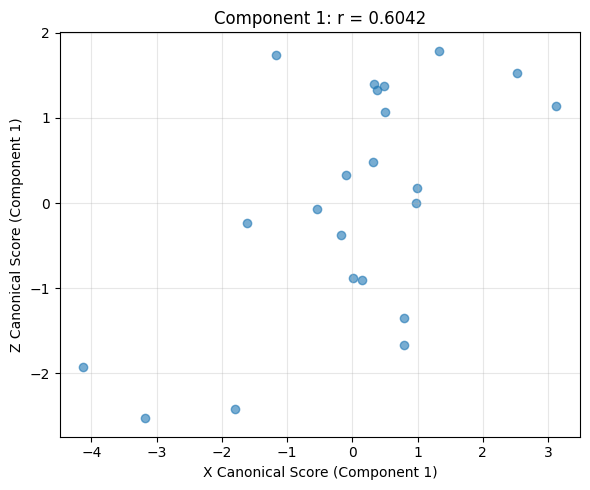

Permutation Test for Statistical Significance
Observed statistic (sum of squared correlations): 0.365117
Running 1000 permutations...

Permutation p-value: 0.1600
95% percentile of permuted statistics: 0.440514
99% percentile of permuted statistics: 0.545817


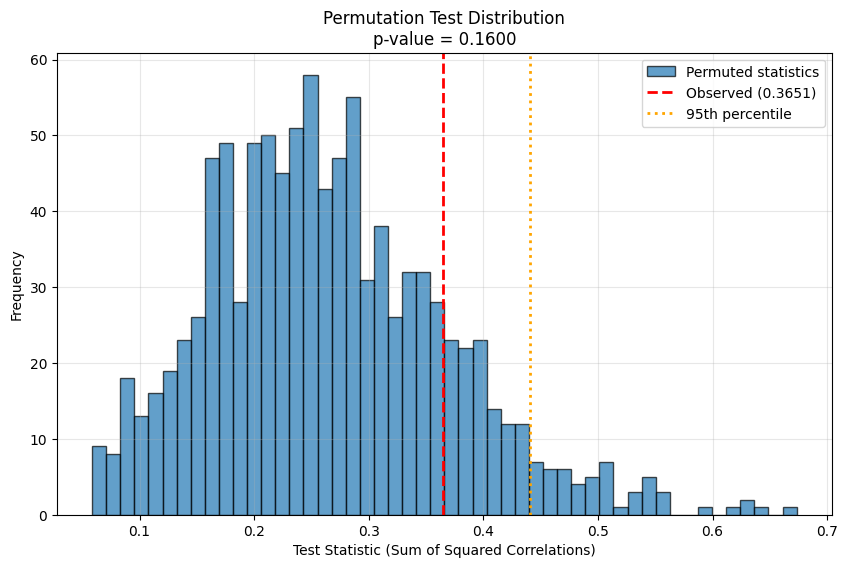

Best n_components: 1
Correlations: [np.float64(0.6042493504517659)]
Permutation p-value: 0.16


In [36]:
# SCCA 함수 사용

from sklearn.datasets import load_diabetes
X_all, y = load_diabetes(return_X_y=True, as_frame=True)

# 데이터를 22개로 제한
X_all = X_all.iloc[:22]

# X 변수 이름
X_cols =['s1','s2','s3', 's4','s5','s6']
# Z 변수 이름
Z_cols = ['age','sex', 'bmi','bp']

X = X_all[X_cols]
Z = X_all[Z_cols]

results = apply_sparse_cca(X, Z, X_cols=X_cols, Z_cols=Z_cols)

# 결과 접근
print(f"Best n_components: {results['best_n']}")
print(f"Correlations: {results['correlations']}")
print(f"Permutation p-value: {results['permutation_pvalue']}")

### 3. Partial correlation analysis - 부분 상관관계 분석

두 변수 사이의 관계를 볼 때, 영향을 줄 수 잇는 다른 변수를 통제한 뒤 순수한 상관만 확인하고 싶을 때 사용

In [16]:
# distance, tolls를 통제변수를 둔 후에 fare과 tip의 부분 상관관계 분석
columns = ['fare']
for c in columns:
   print('result of tip & ', c, '\n',pg.partial_corr(data=df, x='tip', y= c , covar=['distance', 'tolls'], method='pearson'))

result of tip &  fare 
             n        r         CI95%         p-val
pearson  6433  0.19562  [0.17, 0.22]  1.710882e-56


### 4. Partial Least Squares Regression - 부분최소제곱 회귀

설명변수(X)가 많고 서로 상관이 큰 상황에서, X를 몇 개의 성분으로 압축하면서 목표변수(y)를 잘 예측하는 회귀모형을 만들고 싶을 때 사용

In [17]:
X = df[['distance', 'tolls', 'tip', 'passengers']]
y = df[['fare']]

scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

In [20]:
pls = PLSRegression(n_components=1)
pls.fit(X_scaled, y_scaled)

# 예측
y_pred = pls.predict(X_scaled)

# Correlation 계산
r, p = pearsonr(y_scaled[:, 0], y_pred[:, 0])
print(f"PLSR : Component과 fare의 correlation: {r:.4f} (p={p:.4f})")

# Weights 확인 
weights = pd.Series(pls.x_weights_[:, 0], index=X_cols).sort_values(key=abs, ascending=False)
print("\n=== PLSR Weights ===")
print(weights)

PLSR : Component과 fare의 correlation: 0.8670 (p=0.0000)

=== PLSR Weights ===
distance      0.762361
tolls         0.504845
tip           0.404843
passengers    0.006328
dtype: float64


distance, tolls, tip을 결합한 plsr모델은 훈련 데이터에서 fare을 잘 맞춤(r=0.9238)

In [ ]:
from sklearn.model_selection import permutation_test_score

pls = PLSRegression(n_components=1)
score, perm_scores, p_perm = permutation_test_score(
    pls,
    X_scaled,
    y_scaled.ravel(),
    n_permutations=1000,
    random_state=42
)

print(f"Permutation test p-value: {p_perm:.4f}")

Permutation test p-value: 0.0010


결과: 교차검증 cv를 통해 74.65% 설명한다는 것을 알 수 있으며, permutation test 결과로도 통계적으로 유의미한 예측 성능을 보임

### 5. 결측치 처리 방법 비교

먼저 데이터셋을 실제 데이터와 유사하게 변형

In [35]:
from sklearn.datasets import load_diabetes
df_d = load_diabetes()
df_d1 = pd.DataFrame(df_d.data, columns=df_d.feature_names)
print(df_d1.isna().sum())

age    0
sex    0
bmi    0
bp     0
s1     0
s2     0
s3     0
s4     0
s5     0
s6     0
dtype: int64


In [36]:
# 실제 데이터와 비슷하게 44개만 추출
df_s = df_d1.sample(n=44, random_state=42)
df_s.shape

(44, 10)

In [23]:
columns = ['bp', 's1', 's2', 's3', 's4', 's5']
for c in columns:
   print('result of age & ', c, '\n',pg.partial_corr(data=df_s, x='bmi', y= c , covar=['age'], method='pearson'))

result of age &  bp 
           n         r        CI95%     p-val
pearson  44  0.391124  [0.1, 0.62]  0.009503
result of age &  s1 
           n         r          CI95%     p-val
pearson  44  0.189335  [-0.12, 0.46]  0.223984
result of age &  s2 
           n         r         CI95%     p-val
pearson  44  0.241239  [-0.06, 0.5]  0.119136
result of age &  s3 
           n         r           CI95%     p-val
pearson  44 -0.354973  [-0.59, -0.06]  0.019504
result of age &  s4 
           n         r        CI95%    p-val
pearson  44  0.391087  [0.1, 0.62]  0.00951
result of age &  s5 
           n         r         CI95%     p-val
pearson  44  0.377376  [0.09, 0.61]  0.012606


In [38]:
# 결측치도 10개 추가
column = ['bmi', 'bp', 's1', 's2', 's3']
nan_indices = np.random.choice(df_s.index, size=10, replace=False)
df_s.loc[nan_indices, column] = np.nan

In [39]:
df_s.isna().sum()

age     0
sex     0
bmi    10
bp     10
s1     10
s2     10
s3     10
s4      0
s5      0
s6      0
dtype: int64

#### (1) 다중대체

In [26]:
impute_cols = ['bmi', 'bp', 's1', 's2', 's3']
keep_cols_mice = ['s4', 's5', 's6']

# 사용 가능한 컬럼만 선택
available_cols_mice = [col for col in keep_cols_mice if col in df_s.columns]
use_cols_mice = available_cols_mice + impute_cols
df_sub_mice = df_s[use_cols_mice].copy().reset_index(drop=True)

kernel_mice = mf.ImputationKernel(
    data=df_sub_mice,
    num_datasets=5,
    save_all_iterations_data=True,
    random_state=42
)
kernel_mice.mice(iterations=10)

df_mice = df_s.copy()

In [27]:
# 5개의 mice 결과 dataset의 평균 - 새로운 데이터셋 df_mean으로 저장
m = kernel_mice.num_datasets
stack = np.stack([
    kernel_mice.complete_data(dataset=i)[impute_cols].to_numpy()
    for i in range(m)
], axis=0)

df_mean = df_s.copy()
df_mean[impute_cols] = stack.mean(axis=0)
df_mean.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
287,0.045341,-0.044642,-0.006206,-0.015999,0.125019,0.125198,0.019187,0.034309,0.032432,-0.005220
211,0.092564,-0.044642,-0.024529,-0.013706,-0.003770,0.008143,0.015505,-0.039493,-0.022517,-0.021788
72,0.063504,0.050680,0.023973,-0.022430,0.044113,0.031504,-0.000694,-0.002592,0.084492,-0.017646
321,0.096197,-0.044642,0.051996,0.079265,0.054845,0.036577,-0.076536,0.141322,0.098648,0.061054
73,0.012648,0.050680,-0.020218,-0.002228,0.038334,0.053174,-0.006584,0.034309,-0.005142,-0.009362


In [28]:
columns = ['bp', 's1', 's2', 's3', 's4', 's5']
for c in columns:
   print('result of age & ', c, '\n',pg.partial_corr(data=df_mean, x='bmi', y= c , covar=['age'], method='pearson'))

result of age &  bp 
           n         r         CI95%     p-val
pearson  44  0.429342  [0.15, 0.65]  0.004066
result of age &  s1 
           n         r          CI95%     p-val
pearson  44  0.150037  [-0.16, 0.43]  0.336895
result of age &  s2 
           n         r          CI95%     p-val
pearson  44  0.144508  [-0.16, 0.43]  0.355201
result of age &  s3 
           n         r           CI95%     p-val
pearson  44 -0.488627  [-0.69, -0.22]  0.000886
result of age &  s4 
           n         r         CI95%     p-val
pearson  44  0.477558  [0.21, 0.68]  0.001202
result of age &  s5 
           n         r         CI95%     p-val
pearson  44  0.613725  [0.38, 0.77]  0.000012


#### (2) Low-rank matrix completion

In [45]:
df_num = df_s.select_dtypes(include=np.number)
X = df_num.to_numpy() 
si = SoftImpute(max_iters=200, verbose=True)
X_filled = si.fit_transform(X)
df_num_filled = pd.DataFrame(X_filled, columns=df_num.columns)
df_s[df_num.columns] = df_num_filled

[SoftImpute] Max Singular Value of X_init = 0.591175
[SoftImpute] Iter 1: observed MAE=0.001485 rank=10
[SoftImpute] Iter 2: observed MAE=0.001491 rank=10
[SoftImpute] Iter 3: observed MAE=0.001496 rank=10
[SoftImpute] Iter 4: observed MAE=0.001503 rank=10
[SoftImpute] Iter 5: observed MAE=0.001510 rank=10
[SoftImpute] Iter 6: observed MAE=0.001513 rank=10
[SoftImpute] Iter 7: observed MAE=0.001515 rank=10
[SoftImpute] Iter 8: observed MAE=0.001516 rank=10
[SoftImpute] Iter 9: observed MAE=0.001517 rank=10
[SoftImpute] Iter 10: observed MAE=0.001518 rank=10
[SoftImpute] Iter 11: observed MAE=0.001519 rank=10
[SoftImpute] Iter 12: observed MAE=0.001519 rank=10
[SoftImpute] Iter 13: observed MAE=0.001520 rank=10
[SoftImpute] Iter 14: observed MAE=0.001521 rank=10
[SoftImpute] Iter 15: observed MAE=0.001521 rank=10
[SoftImpute] Iter 16: observed MAE=0.001522 rank=10
[SoftImpute] Iter 17: observed MAE=0.001522 rank=10
[SoftImpute] Iter 18: observed MAE=0.001522 rank=10
[SoftImpute] Iter 19

In [47]:
df_s.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
287,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
211,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
72,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
321,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
73,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### (3) 삭제

In [41]:
cols =['bmi', 'bp', 's1', 's2', 's3'] 
df_del = df_s.dropna(subset=cols)
df_del.shape

(34, 10)

In [42]:
columns = ['bp', 's1', 's2', 's3', 's4', 's5']
for c in columns:
   print('result of age & ', c, '\n',pg.partial_corr(data=df_del, x='bmi', y= c , covar=['age'], method='pearson'))

result of age &  bp 
           n         r         CI95%     p-val
pearson  34  0.418073  [0.09, 0.67]  0.015474
result of age &  s1 
           n        r          CI95%     p-val
pearson  34  0.24622  [-0.11, 0.54]  0.167198
result of age &  s2 
           n         r         CI95%     p-val
pearson  34  0.324681  [-0.02, 0.6]  0.065251
result of age &  s3 
           n         r          CI95%     p-val
pearson  34 -0.314115  [-0.59, 0.03]  0.075035
result of age &  s4 
           n         r         CI95%     p-val
pearson  34  0.387261  [0.05, 0.64]  0.025977
result of age &  s5 
           n         r          CI95%     p-val
pearson  34  0.312456  [-0.03, 0.59]  0.076671
